In [1]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import os
import csv
import pandas as pd

import scipy.stats
from sklearn.linear_model import LinearRegression

import torch
from networks_update import Encoder, Decoder
import math
import random

In [2]:
# helper functions
def plot_img(img_arr, slice_idx, title="", cmap="gray"):
    plt.figure(figsize=(2,2))
    plt.imshow(img_arr[slice_idx, :, :], cmap)
    plt.title(title)
    plt.colorbar()
    plt.show()

## Notebook for maping between latents and prelim evaluation of the translation

#### Translating

In [3]:
# folder to save model checkpoints
encoder_save_folder = "./save_models/mouse_train_5/"
decoder_save_folder = "./save_models/human_train_5/"

# checkpoint to load
encoder_epoch = 500
decoder_epoch = 500

# Encode with mouse encoder and decode with human decoder
test_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/test/images/"
test_paths = [test_folder + file_name for file_name in os.listdir(test_folder)]
test_paths.sort()
idx = 2

img = sitk.ReadImage(test_paths[idx])
img_arr = sitk.GetArrayFromImage(img)
img_arr = np.expand_dims(img_arr, axis=0)
img_torch = torch.from_numpy(img_arr).to(torch.float)

# Initialize model
encoder = Encoder(n_downsample=2, n_res=4, input_dim=1, dim=4, norm='in', activ='relu', pad_type='zero')
decoder_recon = Decoder(n_upsample=2, n_res=4, dim=encoder.output_dim, output_dim=4)
decoder_trans = Decoder(n_upsample=2, n_res=4, dim=encoder.output_dim, output_dim=4)

# load models checkpoint to test
encoder.load_state_dict(torch.load(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))['encoder_state_dict'])
decoder_recon.load_state_dict(torch.load(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))['decoder_state_dict'])
decoder_trans.load_state_dict(torch.load(decoder_save_folder + "checkpoint_epoch_" + str(decoder_epoch))['decoder_state_dict'])

z = encoder(img_torch.unsqueeze(0))

recon_img = decoder_recon(z)
recon_img = torch.argmax(recon_img, dim=1)
recon_img = np.array(recon_img.squeeze())

trans_img = decoder_trans(z)
trans_img = torch.argmax(trans_img, dim=1)
trans_img = np.array(trans_img.squeeze())

In [ ]:
# Test 1 - what does the model produce when passed the encoding of the other species (mouse -> human)
# Q1 - does the produced img look reasonable??

slice_idx = 60
plot_img(img_arr.squeeze(), slice_idx, "Img")
plot_img(recon_img, slice_idx, "Recon")
plot_img(trans_img, slice_idx, "Trans")

In [ ]:
# Translate all images in folder to their latent encodings

folder_to_encode = test_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/train/images/"
save_path = "./save_models/mouse_train_5/train_latent_encodings/"
encoder_save_folder = "./save_models/mouse_train_5/"
encoder_epoch = 500

# folder_to_encode = test_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/train/labels/"
# save_path = "./save_models/human_train_5/train_latent_encodings/"
# encoder_save_folder = "./save_models/human_train_5/"
# encoder_epoch = 500

#os.mkdir(save_path)

# Initialize model
encoder = Encoder(n_downsample=2, n_res=4, input_dim=1, dim=4, norm='in', activ='relu', pad_type='zero')

# load models checkpoint to test
encoder.load_state_dict(torch.load(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))['encoder_state_dict'])

for file_name in os.listdir(folder_to_encode):
    img = sitk.ReadImage(folder_to_encode + file_name)
    img_arr = sitk.GetArrayFromImage(img)
    img_arr = np.expand_dims(img_arr, axis=0)
    img_torch = torch.from_numpy(img_arr).to(torch.float)

    z = encoder(img_torch.unsqueeze(0))

    torch.save(z, save_path + "encoded_" + file_name + ".pt")



#### Mapping

In [ ]:
# Test out different models to learn the mapping between latent vectors

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

class ElementWiseLinear(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))  # scaling factors
        #self.bias = nn.Parameter(torch.zeros(dim))   # biases

    def forward(self, x):
        return x * self.weight # + self.bias


latent_shape = [16, 32, 30, 30]
latent_len = math.prod(latent_shape)
middle_feat = 1024

MLP = nn.Sequential(
    nn.Linear(latent_len, middle_feat),  # compress
    nn.ReLU(),
    nn.Linear(middle_feat, middle_feat),    # map in latent space
    nn.ReLU(),
    nn.Linear(middle_feat, latent_len)   # reconstruct
)

class LatentVectorDataset(Dataset):
    def __init__(self, mouse_encodings_folder, human_encodings_folder):
        self.mouse_encodings_folder = mouse_encodings_folder
        self.human_encodings_folder = human_encodings_folder

        self.mouse_encodings_files = os.listdir(mouse_encodings_folder)
        random.shuffle(self.mouse_encodings_files)
        self.human_encodings_files = os.listdir(human_encodings_folder)
    
    def __len__(self):
        return len(self.mouse_encodings_files)
    
    def __getitem__(self, idx):
        mouse_encoding = torch.load(self.mouse_encodings_folder + self.mouse_encodings_files[idx]).flatten().detach()
        human_encoding = torch.load(self.human_encodings_folder + self.human_encodings_files[idx]).flatten().detach()
        return mouse_encoding, human_encoding
    
class LatentVectorAllToAllDataset(Dataset):
    def __init__(self, mouse_encodings_folder, human_encodings_folder):
        self.mouse_encodings_folder = mouse_encodings_folder
        self.human_encodings_folder = human_encodings_folder

        self.mouse_encodings_files = os.listdir(mouse_encodings_folder)
        self.human_encodings_files = os.listdir(human_encodings_folder)

        num_samples = len(self.mouse_encodings_files)
        self.mouse_idxs = np.ones(num_samples**2, dtype=int)

        # To pair every idx with every idx...
        for i in range(num_samples):
            # set mouse_idxs to be [0, 0, ..., 1, 1, ..., ......, num_samples-1, num_samples-1, ...]
            self.mouse_idxs[i*num_samples : (i+1)*num_samples] = i

        # set human_idxs to be [0, 1, ..., num_samples-1, ........, 0, 1, ..., num_samples-1]
        self.human_idxs = np.arange(num_samples**2) % num_samples

        # Shuffle the pairs to get the train dataset

        perm = np.random.permutation(num_samples**2)
        self.human_idxs = self.human_idxs[perm]
        self.mouse_idxs = self.mouse_idxs[perm]
    
    def __len__(self):
        return len(self.mouse_idxs)
    
    def __getitem__(self, idx):
        mouse_encoding = torch.load(self.mouse_encodings_folder + self.mouse_encodings_files[self.mouse_idxs[idx]]).flatten().detach()
        human_encoding = torch.load(self.human_encodings_folder + self.human_encodings_files[self.human_idxs[idx]]).flatten().detach()
        return mouse_encoding, human_encoding
    

# load data into random ordered vectors
mouse_encodings_folder = "./save_models/mouse_train_5/train_latent_encodings/"
human_encodings_folder = "./save_models/human_train_5/train_latent_encodings/"

dataset = LatentVectorDataset(mouse_encodings_folder, human_encodings_folder)
batch_size = 4
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

model = MLP.cuda() #ElementWiseLinear(latent_len).cuda()  # move to GPU
model.load_state_dict(torch.load('./save_mapping_models/train_5/test_3_MLP_middle_1024.pth'))

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
start_epoch = 101
epochs = 100
save_loss = []
print("start training!!")
for epoch in range(start_epoch, epochs + start_epoch):
    running_loss = 0.0
    for mouse_batch, human_batch in dataloader:
        mouse_batch = mouse_batch.cuda()
        human_batch = human_batch.cuda()

        optimizer.zero_grad()
        outputs = model(mouse_batch)
        loss = criterion(outputs, human_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * mouse_batch.size(0)

    epoch_loss = running_loss / len(dataset)
    save_loss.append(epoch_loss)
    print(f"Epoch {epoch + 1}, Loss: {epoch_loss:.6f}")

# one epoch ~10s


start training!!
Epoch 102, Loss: 1.959240
Epoch 103, Loss: 1.866173
Epoch 104, Loss: 1.779576
Epoch 105, Loss: 1.698594
Epoch 106, Loss: 1.622907
Epoch 107, Loss: 1.552031
Epoch 108, Loss: 1.485517
Epoch 109, Loss: 1.423176
Epoch 110, Loss: 1.364491
Epoch 111, Loss: 1.309515
Epoch 112, Loss: 1.257781
Epoch 113, Loss: 1.209098
Epoch 114, Loss: 1.163298
Epoch 115, Loss: 1.120193
Epoch 116, Loss: 1.079521
Epoch 117, Loss: 1.041256
Epoch 118, Loss: 1.005170
Epoch 119, Loss: 0.971182
Epoch 120, Loss: 0.939076
Epoch 121, Loss: 0.908752
Epoch 122, Loss: 0.880201
Epoch 123, Loss: 0.853228
Epoch 124, Loss: 0.827769
Epoch 125, Loss: 0.803690
Epoch 126, Loss: 0.781010
Epoch 127, Loss: 0.759484
Epoch 128, Loss: 0.739221
Epoch 129, Loss: 0.720006
Epoch 130, Loss: 0.701878
Epoch 131, Loss: 0.684730
Epoch 132, Loss: 0.668492
Epoch 133, Loss: 0.653122
Epoch 134, Loss: 0.638628
Epoch 135, Loss: 0.624848
Epoch 136, Loss: 0.611821
Epoch 137, Loss: 0.599444
Epoch 138, Loss: 0.587827
Epoch 139, Loss: 0.57

In [ ]:
# save the mapping model

#torch.save(model.state_dict(), 'test_1_element_wise.pth')
#torch.save(model.state_dict(), 'test_2_element_wise_1_to_1.pth')
torch.save(model.state_dict(), './save_mapping_models/train_5/test_3_MLP_middle_1024_epoch_201.pth')
#torch.save(model.state_dict(), './save_mapping_models/train_5/test_3_MLP_middle_1024_all_to_all_8_epoch.pth')

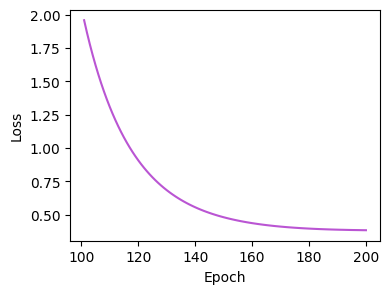

In [ ]:
# plot loss

plt.figure(figsize=(4,3))
plt.plot(np.arange(start_epoch, epochs + start_epoch), save_loss, color="mediumorchid")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
# Now test the translating model!!!
# (for a sample decode to reconstructed and transaated - with model trained above)

# folder to save model checkpoints
encoder_save_folder = "./save_models/mouse_train_5/"
decoder_save_folder = "./save_models/human_train_5/"

# checkpoint to load
encoder_epoch = 500
decoder_epoch = 500

# Encode with mouse encoder and decode with human decoder
test_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/train/images/"
test_paths = [test_folder + file_name for file_name in os.listdir(test_folder)]
test_paths.sort()
idx = 1

img = sitk.ReadImage(test_paths[idx])
img_arr = sitk.GetArrayFromImage(img)
img_arr = np.expand_dims(img_arr, axis=0)
img_torch = torch.from_numpy(img_arr).to(torch.float)

# Initialize model
encoder = Encoder(n_downsample=2, n_res=4, input_dim=1, dim=4, norm='in', activ='relu', pad_type='zero')
decoder_recon = Decoder(n_upsample=2, n_res=4, dim=encoder.output_dim, output_dim=4)
decoder_trans = Decoder(n_upsample=2, n_res=4, dim=encoder.output_dim, output_dim=4)

# load models checkpoint to test
encoder.load_state_dict(torch.load(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))['encoder_state_dict'])
decoder_recon.load_state_dict(torch.load(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))['decoder_state_dict'])
decoder_trans.load_state_dict(torch.load(decoder_save_folder + "checkpoint_epoch_" + str(decoder_epoch))['decoder_state_dict'])

z = encoder(img_torch.unsqueeze(0))

# the translating model trained above
z_trans = model(z.flatten().cuda()).reshape(z.shape)

recon_img = decoder_recon(z)
recon_img = torch.argmax(recon_img, dim=1)
recon_img = np.array(recon_img.squeeze())

trans_img = decoder_trans(z)
trans_img = torch.argmax(trans_img, dim=1)
trans_img = np.array(trans_img.squeeze())

trans_map_img = decoder_trans(z_trans.detach().cpu().reshape(z.shape))
trans_map_img = torch.argmax(trans_map_img, dim=1)
trans_map_img = np.array(trans_map_img.squeeze())

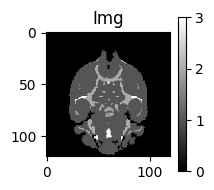

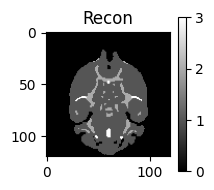

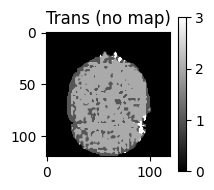

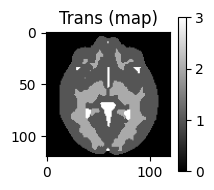

In [15]:
slice_idx = 60
plot_img(img_arr.squeeze(), slice_idx, "Img")
plot_img(recon_img, slice_idx, "Recon")
plot_img(trans_img, slice_idx, "Trans (no map)")
plot_img(trans_map_img, slice_idx, "Trans (map)")